# Import Packages

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
from tqdm import tqdm
from urllib.parse import urlparse
pd.set_option("display.max_colwidth", 200)
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.pipeline import FeatureUnion
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import BernoulliNB, ComplementNB, MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack
%matplotlib inline

# Load Datasets

In [2]:
df = pd.read_csv("./dataset/webpage data.csv")

#### Basic Exploration

In [3]:
df.shape

(53229, 4)

In [4]:
df.head()

,Webpage_id,Domain,Url,Tag
0,1,www.fiercepharma.com,http://www.fiercepharma.com/marketing/tecfidera-gilenya-and-aubagio-s-3-way-battle-for-ms-share-about-to-get-more-interesting,news
1,2,www.fiercepharma.com,http://www.fiercepharma.com/pharma/novo-equipped-to-weather-storm-u-s-diabetes-market-ceo-says,news
2,3,www.fiercepharma.com,http://www.fiercepharma.com/pharma/another-exec-departs-troubled-endo-and-time-it-s-for-another-drugmaker,news
3,4,www.fiercepharma.com,http://www.fiercepharma.com/pharma/teva-buy-biosim-specialist-celltrion-it-wouldn-t-say-no,news
4,5,www.fiercepharma.com,http://www.fiercepharma.com/marketing/actress-marissa-tomei-partners-allergan-restasis-to-drive-dry-eye-awareness,news


In [5]:
df['Tag'].unique()

<StringArray>
[          'news', 'clinicalTrials',    'conferences',        'profile',
          'forum',    'publication',         'thesis',     'guidelines',
         'others']
Length: 9, dtype: str

In [6]:
df[df['Tag'] == 'profile'].head(2)

,Webpage_id,Domain,Url,Tag
3476,5096,www.healthcare4ppl.com,http://www.healthcare4ppl.com/physician/wisconsin/waukesha/andrew-v-beykovsky-1114036092.html,profile
3477,5097,www.healthcare4ppl.com,http://www.healthcare4ppl.com/physician/west-virginia/morgantown/clare-m-mcdaniel-1346231032.html,profile


In [7]:
df[df['Tag'] == 'conferences'].head(2)

,Webpage_id,Domain,Url,Tag
550,1028,investors.alphatecspine.com,http://investors.alphatecspine.com/events.cfm,conferences
1033,1773,ir.alk.net,http://ir.alk.net/events.cfm,conferences


In [8]:
df[df['Tag'] == 'forum'].head(2)

,Webpage_id,Domain,Url,Tag
3689,5549,community.beatingbowelcancer.org,http://community.beatingbowelcancer.org/forum/926-post-op,forum
3765,5714,rollitup.org,http://rollitup.org/t/someguys-led-other-grows-2014-15-season.851562/page-82,forum


In [9]:
df[df['Tag'] == 'others'].head(2)

,Webpage_id,Domain,Url,Tag
6970,10229,joannabriggs.org,http://joannabriggs.org/,others
7152,10679,www.copdx.org.au,http://copdx.org.au/,others


# Target Exploration

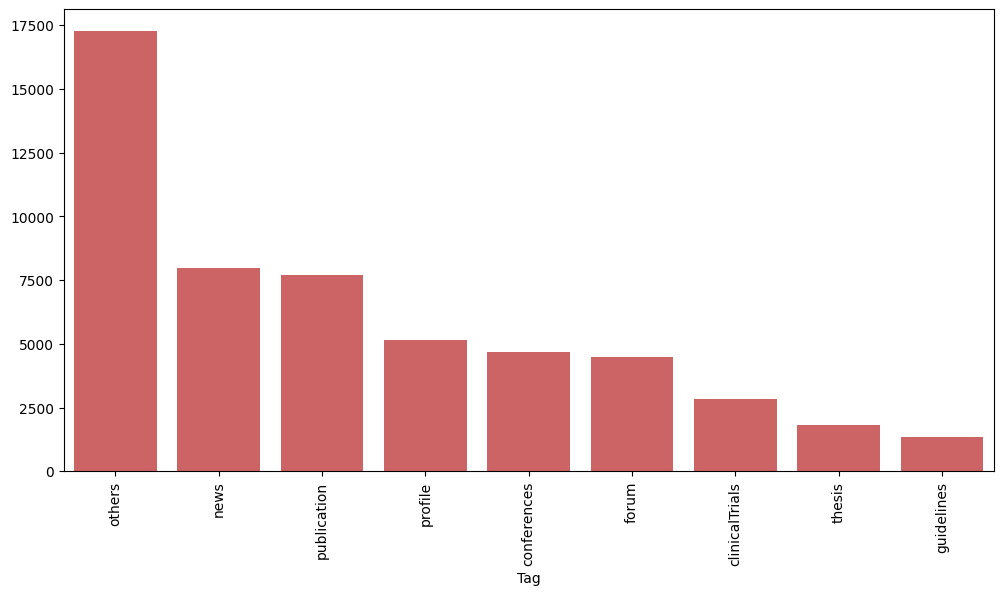

In [10]:
cnt_tag = df['Tag'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=cnt_tag.index, y=cnt_tag.values, alpha=0.8, color=color[3])
plt.xticks(rotation='vertical')
plt.show()

# Understanding the Common Words Used in the URLs: WordCloud

In [11]:
all_words = ' '.join([text for text in df['Url']])
from wordcloud import WordCloud
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

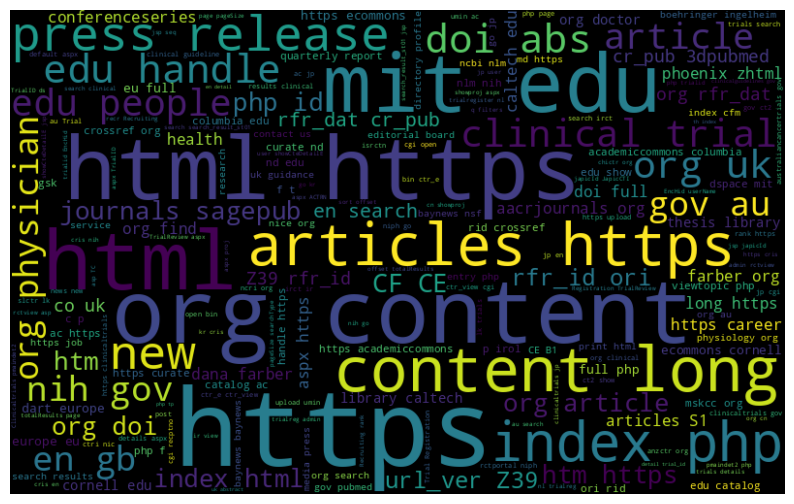

In [12]:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

#### Word Cloud for the Tag: Thesis

In [13]:
all_words = ' '.join([text for text in df[df['Tag'] == 'thesis']['Url']])
wordcloud = WordCloud(width=800, height=500, random_state=21,
             max_font_size=110).generate(all_words)

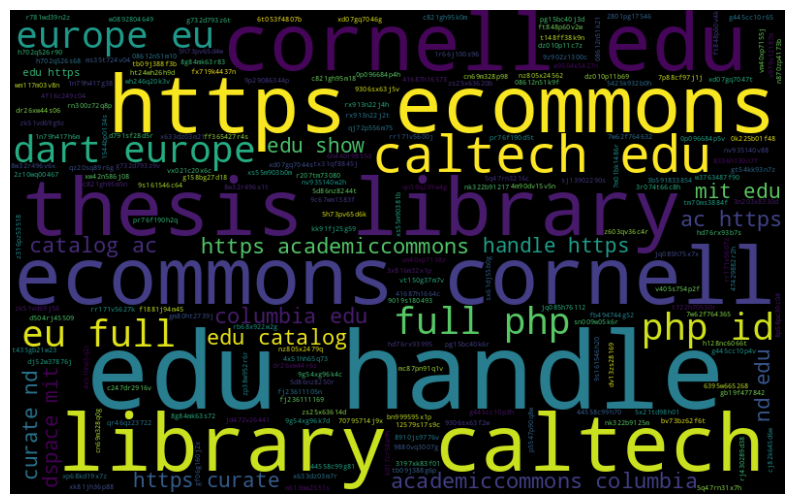

In [14]:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

# Feature Extraction

In [15]:
def clean_url(df):
    df["Url"] = df["Url"].str.replace("/", " ")
    df["Url"] = df["Url"].str.replace("-", " ")
    df["Url"] = df["Url"].str.replace("https:", "")
    df["Url"] = df["Url"].str.replace("http:", "")
    return df

In [16]:
df = clean_url(df)

In [17]:
df.head(5)

,Webpage_id,Domain,Url,Tag
0,1,www.fiercepharma.com,www.fiercepharma.com marketing tecfidera gilenya and aubagio s 3 way battle for ms share about to get more interesting,news
1,2,www.fiercepharma.com,www.fiercepharma.com pharma novo equipped to weather storm u s diabetes market ceo says,news
2,3,www.fiercepharma.com,www.fiercepharma.com pharma another exec departs troubled endo and time it s for another drugmaker,news
3,4,www.fiercepharma.com,www.fiercepharma.com pharma teva buy biosim specialist celltrion it wouldn t say no,news
4,5,www.fiercepharma.com,www.fiercepharma.com marketing actress marissa tomei partners allergan restasis to drive dry eye awareness,news


### Bag-of-Words Features

In [18]:
# Word and character BOW on URLs
vec_bow = CountVectorizer(ngram_range=(1, 3), min_df=400)
vec_bow.fit(df['Url'])
Url_bow = vec_bow.transform(df['Url'])

#### Train Test Split

In [19]:
# Replicate train/test split strategy for cross validation
df["target_str"] = df["Domain"].astype(str) + '_' + df["Tag"].astype(str)
cvlist = list(GroupKFold(5).split(df, groups=df["target_str"]))

In [20]:
df["target_str"].head()

0    www.fiercepharma.com_news
1    www.fiercepharma.com_news
2    www.fiercepharma.com_news
3    www.fiercepharma.com_news
4    www.fiercepharma.com_news
Name: target_str, dtype: str

In [21]:
X = Url_bow

In [22]:
TAG_DICT = {"others":1, "news": 2, "publication":3, "profile": 4,
            "conferences": 5, "forum": 6, "clinicalTrials": 7,
            "thesis": 8, "guidelines": 9}

In [23]:
df['target'] = df.Tag.map(TAG_DICT)
y = df["target"].values

# Model Building and Model Validation

In [24]:
def cv_score(ml_model, df):
    i = 1
    cv_scores = []
    X = df
    
    # Custom Cross validation based on group KFold
    for df_index,test_index in cvlist:
        print('n{} of Group kfold {}'.format(i,5))
        xtr,xvl = X[df_index],X[test_index]
        ytr,yvl = y[df_index],y[test_index]
            
        # Define model for fitting on the training set for each fold
        model = ml_model
        model.fit(xtr, ytr)
        pred_probs = model.predict_proba(xvl)
        label_preds = np.argmax(pred_probs, axis=1) + 1
        
        # Calculate scores for each fold and print
        score = f1_score(yvl, label_preds, average="weighted")
        sufix = ""
        msg = ""
        msg += "Weighted F1 Score: {}".format(score)
        print("{}".format(msg))
         
         # Save scores
        cv_scores.append(score)
        i+=1
    return cv_scores

#### Naive Bayes

In [25]:
cv_score(MultinomialNB(alpha=.01), Url_bow)

n1 of Group kfold 5
Weighted F1 Score: 0.6727038244454654
n2 of Group kfold 5
Weighted F1 Score: 0.604835304808472
n3 of Group kfold 5
Weighted F1 Score: 0.6748153323539996
n4 of Group kfold 5
Weighted F1 Score: 0.6481203703628978
n5 of Group kfold 5
Weighted F1 Score: 0.6196220567798797


[0.6727038244454654,
 0.604835304808472,
 0.6748153323539996,
 0.6481203703628978,
 0.6196220567798797]

#### Character N-Grams

In [26]:
# Word and character BOW on URLs
vec1 = CountVectorizer(analyzer='char', ngram_range=(1, 5), min_df=500)
vec2 = CountVectorizer(analyzer='word', ngram_range=(1, 3), min_df=400)
vec_bow = FeatureUnion([("char", vec1), ("word", vec2)])
vec_bow.fit(df['Url'])
Url_bow = vec_bow.transform(df['Url'])

In [27]:
cv_score(MultinomialNB(alpha=.01), Url_bow)

n1 of Group kfold 5
Weighted F1 Score: 0.7299565101188273
n2 of Group kfold 5
Weighted F1 Score: 0.671350963990774
n3 of Group kfold 5
Weighted F1 Score: 0.7067511633265192
n4 of Group kfold 5
Weighted F1 Score: 0.6834919307083858
n5 of Group kfold 5
Weighted F1 Score: 0.6990068002160931


[0.7299565101188273,
 0.671350963990774,
 0.7067511633265192,
 0.6834919307083858,
 0.6990068002160931]

#### TFIDF Features

In [28]:
# Word and character TFIDF on URLs
vec1 = TfidfVectorizer(analyzer='char', ngram_range=(1, 5), min_df=500)
vec2 = TfidfVectorizer(analyzer='word', ngram_range=(1, 3), min_df=400)
vec_tfidf = FeatureUnion([("char", vec1), ("word", vec2)])
vec_tfidf.fit(df['Url'])
Url_tfidf = vec_tfidf.transform(df['Url'])

In [29]:
nb = cv_score(MultinomialNB(alpha=.01), Url_tfidf)

n1 of Group kfold 5
Weighted F1 Score: 0.7381374172871449
n2 of Group kfold 5
Weighted F1 Score: 0.6884064729481048
n3 of Group kfold 5
Weighted F1 Score: 0.7701882863449597
n4 of Group kfold 5
Weighted F1 Score: 0.7036023279788329
n5 of Group kfold 5
Weighted F1 Score: 0.6699460777234888


#### Logistic Regression

In [30]:
log_reg = cv_score(LogisticRegression(C=0.1,class_weight="balanced"), Url_tfidf)

n1 of Group kfold 5
Weighted F1 Score: 0.7309825093318645
n2 of Group kfold 5
Weighted F1 Score: 0.6982704748958586
n3 of Group kfold 5
Weighted F1 Score: 0.7669048985161679
n4 of Group kfold 5
Weighted F1 Score: 0.736301602265429
n5 of Group kfold 5
Weighted F1 Score: 0.7553127819753063


#### Tree Based Methods

In [31]:
dtree = cv_score(DecisionTreeClassifier(min_samples_leaf=25, min_samples_split=25), Url_tfidf)

n1 of Group kfold 5
Weighted F1 Score: 0.6398389885688552
n2 of Group kfold 5
Weighted F1 Score: 0.6414656550529474
n3 of Group kfold 5
Weighted F1 Score: 0.6371568202504115
n4 of Group kfold 5
Weighted F1 Score: 0.6336000981013719
n5 of Group kfold 5
Weighted F1 Score: 0.6558239636453855


#### Random Forest

In [32]:
rf_params = {'random_state': 0, 'n_jobs': -1, 'n_estimators': 100, 'max_depth': 50, 'n_jobs': -1}
rf = cv_score(RandomForestClassifier(**rf_params), Url_tfidf)

n1 of Group kfold 5
Weighted F1 Score: 0.7100508593021013
n2 of Group kfold 5
Weighted F1 Score: 0.6618299303695347
n3 of Group kfold 5
Weighted F1 Score: 0.6769560082537748
n4 of Group kfold 5
Weighted F1 Score: 0.6715044114225678
n5 of Group kfold 5
Weighted F1 Score: 0.6865512388625611


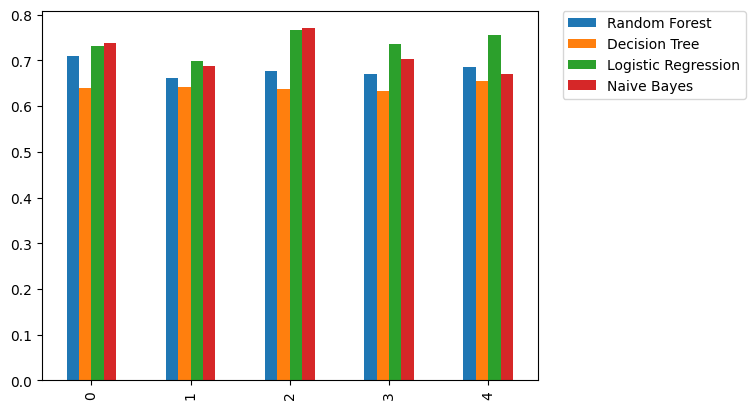

In [33]:
results_df = pd.DataFrame({'Random Forest':rf, 'Decision Tree': dtree, 'Logistic Regression': log_reg, 'Naive Bayes':nb})
results_df.plot(y=["Random Forest", "Decision Tree","Logistic Regression","Naive Bayes"], kind="bar")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()